# MOVE — standalone pipeline

A self-contained, portable version of the tutorial (encode data → train a model &
explore its latent space → identify associations), plus a cell for playing with
and comparing hyperparameters.

**No YAML config files needed.** Every task is built directly from plain Python
objects, so the only things you need on a new machine (e.g. your SSH server) are:

1. `move` installed (e.g. `pip install -e .` from your fork)
2. This notebook
3. Your own raw data: one TSV/CSV file per dataset (samples as rows, features as
   columns), plus a sample-IDs file — same layout as `tutorial/data/`.

Cells marked **EDIT ME** are where you plug in your own dataset names, paths, and
hyperparameters. Everything else can be run as-is.

⚠️ **GPU note:** the current codebase does not yet move training batches to the
GPU automatically, so `use_cuda=True` will crash with a device-mismatch error
mid-training. Leave it `False` for now — ask if you'd like this fixed.

## 0. Emtpying previous result files  

The intermediate and result files are saved in the folders ressult and interim_data. Run this code to clear the result folders and get new output.  

Alternativly, use load resulting result by 

In [18]:
from pathlib import Path
import shutil

for folder in ["results", "interim_data"]:
    path = Path(folder)

    if path.exists():
        shutil.rmtree(path)
        print(f"Deleted: {path}")

Deleted: results
Deleted: interim_data


In [19]:
from pathlib import Path

import pandas as pd

from move.conf.models import VaeConfig
from move.conf.optim import AdamConfig
from move.conf.tasks import InputConfig, PerturbationConfig
from move.conf.training import TrainingLoopConfig
from move.tasks.associations import Associations
from move.tasks.encode_data import EncodeData
from move.tasks.latent_space_analysis import LatentSpaceAnalysis

## 1. Configure your data — EDIT ME

In [20]:
# Where your raw TSV/CSV files live, and where MOVE should write intermediate
# and result files. Each raw dataset file must be named "<name>.tsv" (or .csv)
# inside RAW_DATA_PATH, with samples as rows and features as columns.
RAW_DATA_PATH = Path("data")
INTERIM_DATA_PATH = Path("interim_data")
RESULTS_PATH = Path("results")

# Name of the file (without extension), in RAW_DATA_PATH, listing sample IDs
# (one per line). All datasets are aligned/reindexed to this sample order.
SAMPLE_NAMES = "random.small.ids"

# Categorical (discrete) datasets: one-hot encoded. Give each dataset a name
# (matching its filename) and, optionally, a reconstruction-loss weight
# (default 1 — raise it to make MOVE prioritize reconstructing that dataset).
CATEGORICAL_DATASETS = [
    {"name": "random.small.drugs", "weight": 1},
]

# Continuous datasets: choose "standardize" (z-score only) or
# "log_and_standardize" (base-2 log-transform, log2(x+1), then z-score) per
# dataset. Real proteomics/metagenomics intensities are often right-skewed
# and benefit from log2 -- but this tutorial's "random.small.*" data is
# synthetic and already near-symmetric (skew ~0), so log2 would distort it
# rather than help. Use "standardize" here; switch to "log_and_standardize"
# for real skewed data of your own.
CONTINUOUS_DATASETS = [
    {"name": "random.small.proteomics", "weight": 1, "preprocessing": "standardize"},
    {"name": "random.small.metagenomics", "weight": 1, "preprocessing": "standardize"},
]

TRAIN_FRAC = 0.9
TEST_FRAC = 0.1
VALID_FRAC = 0.0

### 1b. Explore your data (optional) — feature correlations

For each raw dataset, plots a signed Pearson-correlation heatmap (diverging
colormap, centered at 0, so anti-correlated features stand out as clearly as
correlated ones) between its features. Set `CALCULATE_MI` to also compute
mutual information — it captures non-linear dependencies too, but is much
slower for datasets with many features.

Purely exploratory: skip this cell if you already know which features you
want to include/weight.

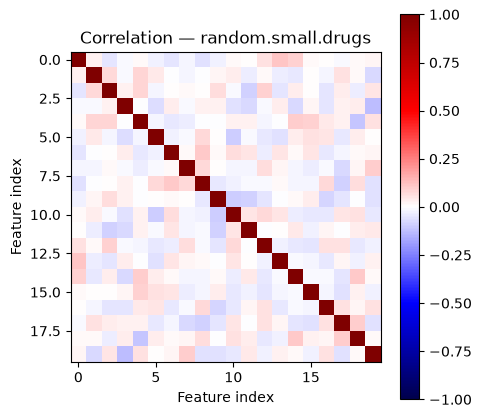

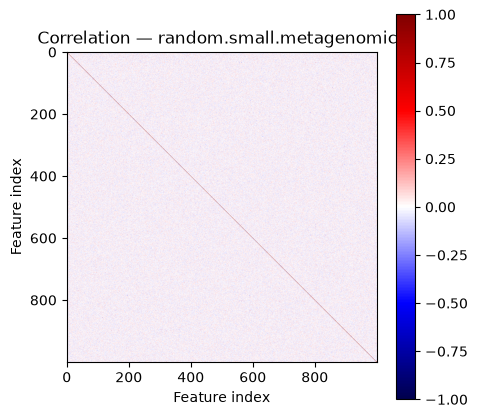

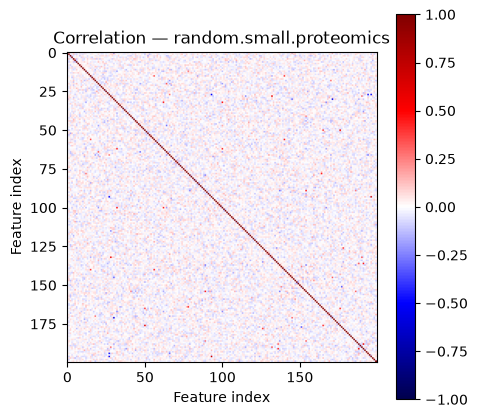

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

CALCULATE_MI = False  # set True to also compute (slow) mutual information matrices

for filepath in sorted(RAW_DATA_PATH.glob("*.tsv")) + sorted(RAW_DATA_PATH.glob("*.csv")):
    sep = "\t" if filepath.suffix == ".tsv" else ","
    ds = pd.read_csv(filepath, sep=sep, index_col=0)
    numeric_ds = ds.select_dtypes(include="number")
    if numeric_ds.shape[1] == 0:
        print(f"Skipping '{filepath.stem}': no numeric columns found")
        continue

    # title, matrix, colormap (diverging + centered at 0 for signed correlation;
    # sequential from 0 for MI, which is never negative), and color limits.
    # NaNs are common in omics data - `.corr()` handles them pairwise, so no
    # rows/columns need to be dropped just because they contain a NaN somewhere.
    panels = [("Correlation", numeric_ds.corr().to_numpy(), "seismic", (-1, 1))]

    if CALCULATE_MI:
        # mutual_info_regression can't handle NaNs; mean-impute just for this estimate
        mi_values = numeric_ds.fillna(numeric_ds.mean()).to_numpy(dtype=np.float64)
        mi = np.zeros((mi_values.shape[1], mi_values.shape[1]))
        for col in range(mi_values.shape[1]):
            mi[col, col:] = mutual_info_regression(mi_values[:, col:], mi_values[:, col])
        mi = mi + mi.T - np.diag(np.diag(mi))  # mirror onto the other triangle
        panels.append(("Mutual information", mi, "inferno", (0, None)))

    fig, axs = plt.subplots(ncols=len(panels), figsize=(5 * len(panels), 5), squeeze=False)
    for ax, (title, matrix, cmap, (vmin, vmax)) in zip(axs[0], panels):
        im = ax.imshow(matrix, cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set(title=f"{title} — {filepath.stem}", xlabel="Feature index", ylabel="Feature index")
        fig.colorbar(im, ax=ax)
    plt.show()

## 2. Encode data

Reads the raw TSV/CSV files, one-hot encodes categorical datasets, standardizes
continuous ones, and writes the result to `INTERIM_DATA_PATH`. Skipped
automatically if all datasets are already encoded there — delete the `.pt`
files in that folder to force re-encoding.

In [22]:
discrete_inputs = [
    InputConfig(d["name"], weight=d.get("weight", 1), preprocessing="one_hot_encode")
    for d in CATEGORICAL_DATASETS
]
continuous_inputs = [
    InputConfig(
        d["name"],
        weight=d.get("weight", 1),
        preprocessing=d.get("preprocessing", "standardize"),
    )
    for d in CONTINUOUS_DATASETS
]

already_encoded = bool(discrete_inputs + continuous_inputs) and all(
    (INTERIM_DATA_PATH / f"{cfg.name}.pt").exists()
    for cfg in discrete_inputs + continuous_inputs
)
if already_encoded:
    print(f"All datasets already encoded in '{INTERIM_DATA_PATH}' - skipping.")
else:
    encode_task = EncodeData(
        raw_data_path=RAW_DATA_PATH,
        interim_data_path=INTERIM_DATA_PATH,
        sample_names_filename=SAMPLE_NAMES,
        discrete_inputs=discrete_inputs,
        continuous_inputs=continuous_inputs,
        train_frac=TRAIN_FRAC,
        test_frac=TEST_FRAC,
        valid_frac=VALID_FRAC,
    )
    encode_task.run()

CATEGORICAL_NAMES = [d["name"] for d in CATEGORICAL_DATASETS]
CONTINUOUS_NAMES = [d["name"] for d in CONTINUOUS_DATASETS]
CATEGORICAL_WEIGHTS = [d.get("weight", 1) for d in CATEGORICAL_DATASETS]
CONTINUOUS_WEIGHTS = [d.get("weight", 1) for d in CONTINUOUS_DATASETS]

[INFO  - EncodeData]: Beginning task: encode data
[INFO  - EncodeData]: Encoding 'random.small.drugs'
[INFO  - EncodeData]: Encoding 'random.small.proteomics'
[INFO  - EncodeData]: Encoding 'random.small.metagenomics'


## 3. Model & training hyperparameters — EDIT ME

In [23]:
BATCH_SIZE = 20

NUM_HIDDEN = [1000]  # sizes of the VAE's hidden encoder/decoder layers
NUM_LATENT = 150     # size of the latent space
KL_WEIGHT = 1e-4     # base weight of the KL-divergence (regularization) term
DROPOUT_RATE = 0.1

LEARNING_RATE = 1e-4
MAX_EPOCHS = 40
ANNEALING_EPOCHS = MAX_EPOCHS // 2  # epochs over which the KL weight is annealed in

USE_CUDA = False  # see the GPU note at the top before flipping this on

## 4. Play & compare hyperparameters — EDIT ME

Trains one model per combo below (accuracy metrics only — dimensionality
reduction and feature importance are skipped here to keep it fast) and plots
mean reconstruction score per dataset, side by side, so you can see which
combo reconstructs your data best.

Add/remove/edit combos freely; any `VaeConfig`/`TrainingLoopConfig` field can
be varied this way, not just the ones listed.

In [24]:
HP_COMBOS = {
    "baseline": dict(num_hidden=[1000], num_latent=150, kl_weight=1e-4, dropout_rate=0.1, lr=1e-4, max_epochs=40),
    "wider_hidden": dict(num_hidden=[2000], num_latent=150, kl_weight=1e-4, dropout_rate=0.1, lr=1e-4, max_epochs=40),
    "more_latent_dims": dict(num_hidden=[1000], num_latent=300, kl_weight=1e-4, dropout_rate=0.1, lr=1e-4, max_epochs=40),
    "stronger_regularization": dict(num_hidden=[1000], num_latent=150, kl_weight=1e-3, dropout_rate=0.1, lr=1e-4, max_epochs=40),
}

--- baseline: {'num_hidden': [1000], 'num_latent': 150, 'kl_weight': 0.0001, 'dropout_rate': 0.1, 'lr': 0.0001, 'max_epochs': 40}


[INFO  - LatentSpaceAnalysis]: Epoch 10
[INFO  - LatentSpaceAnalysis]: Epoch 20
[INFO  - LatentSpaceAnalysis]: Epoch 30
[INFO  - LatentSpaceAnalysis]: Epoch 40


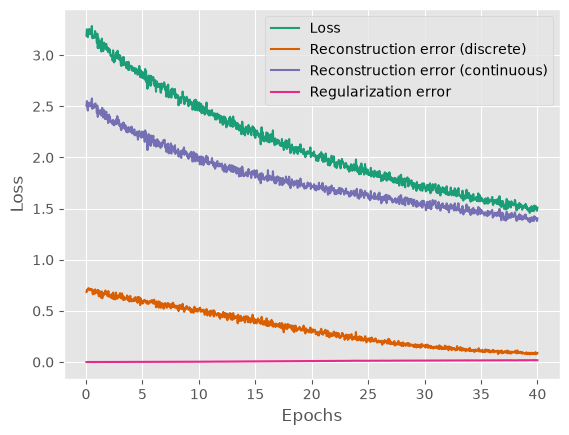

[INFO  - LatentSpaceAnalysis]: Compressing input data
[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


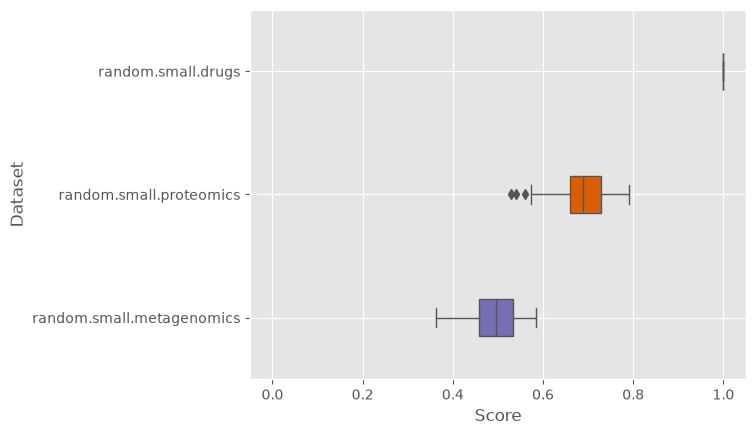

[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


--- wider_hidden: {'num_hidden': [2000], 'num_latent': 150, 'kl_weight': 0.0001, 'dropout_rate': 0.1, 'lr': 0.0001, 'max_epochs': 40}


[INFO  - LatentSpaceAnalysis]: Epoch 10
[INFO  - LatentSpaceAnalysis]: Epoch 20
[INFO  - LatentSpaceAnalysis]: Epoch 30
[INFO  - LatentSpaceAnalysis]: Epoch 40


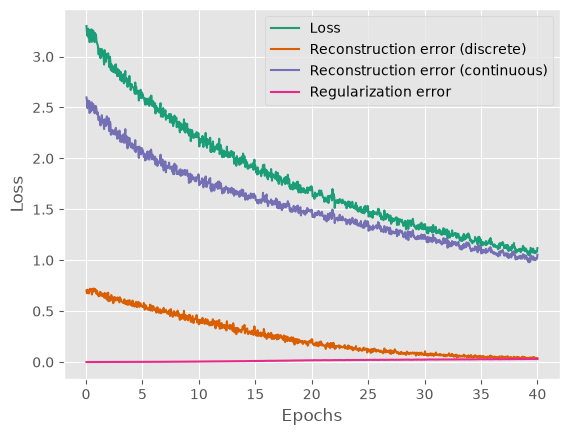

[INFO  - LatentSpaceAnalysis]: Compressing input data
[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


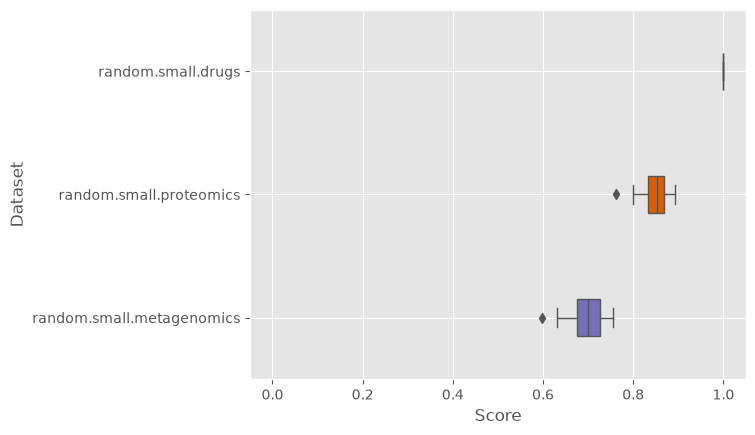

[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


--- more_latent_dims: {'num_hidden': [1000], 'num_latent': 300, 'kl_weight': 0.0001, 'dropout_rate': 0.1, 'lr': 0.0001, 'max_epochs': 40}


[INFO  - LatentSpaceAnalysis]: Epoch 10
[INFO  - LatentSpaceAnalysis]: Epoch 20
[INFO  - LatentSpaceAnalysis]: Epoch 30
[INFO  - LatentSpaceAnalysis]: Epoch 40


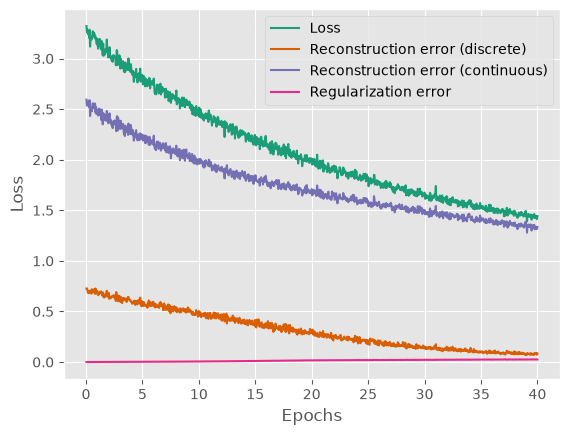

[INFO  - LatentSpaceAnalysis]: Compressing input data
[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


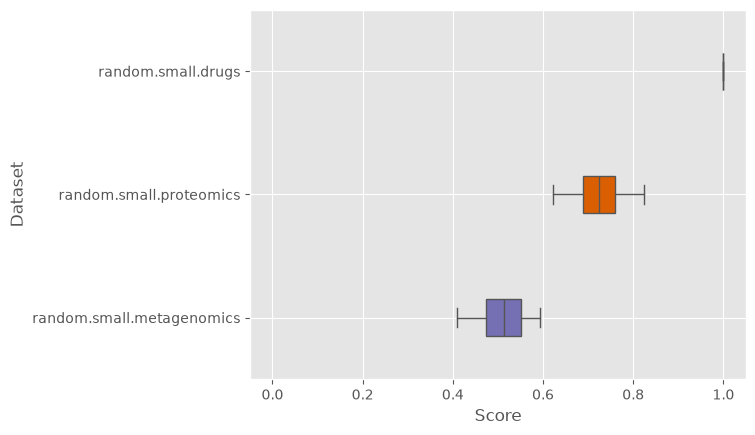

[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


--- stronger_regularization: {'num_hidden': [1000], 'num_latent': 150, 'kl_weight': 0.001, 'dropout_rate': 0.1, 'lr': 0.0001, 'max_epochs': 40}


[INFO  - LatentSpaceAnalysis]: Epoch 10
[INFO  - LatentSpaceAnalysis]: Epoch 20
[INFO  - LatentSpaceAnalysis]: Epoch 30
[INFO  - LatentSpaceAnalysis]: Epoch 40


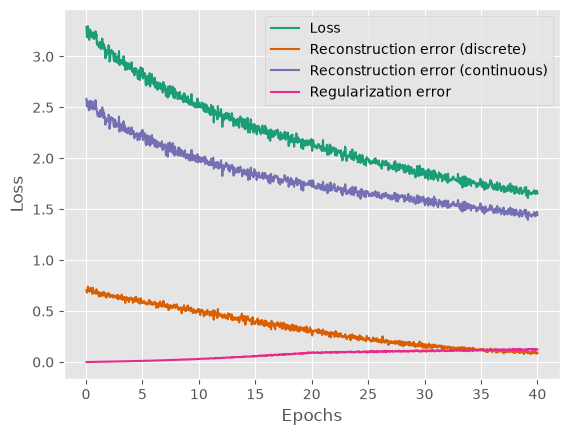

[INFO  - LatentSpaceAnalysis]: Compressing input data
[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


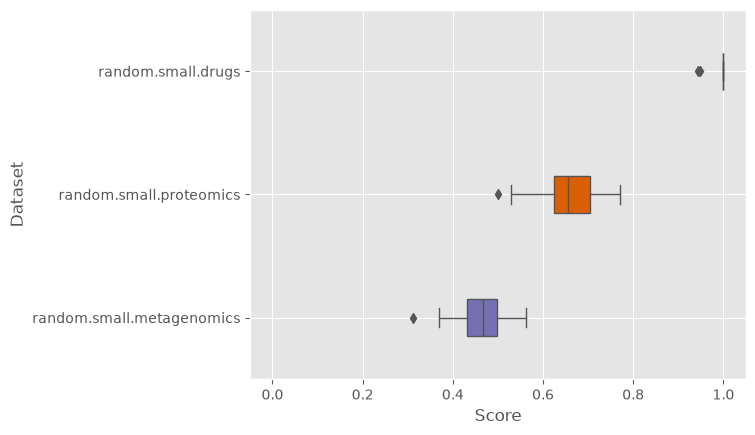

[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


split                                                  test     train
combo                   dataset                                      
baseline                random.small.drugs         1.000000  0.999123
                        random.small.metagenomics  0.493887  0.485959
                        random.small.proteomics    0.687063  0.688195
more_latent_dims        random.small.drugs         1.000000  0.999753
                        random.small.metagenomics  0.512727  0.509616
                        random.small.proteomics    0.722651  0.725367
stronger_regularization random.small.drugs         0.997836  0.997612
                        random.small.metagenomics  0.461163  0.457774
                        random.small.proteomics    0.655510  0.661918
wider_hidden            random.small.drugs         1.000000  1.000000
                        random.small.metagenomics  0.697940  0.691270
                        random.small.proteomics    0.847726  0.843708

In [25]:
from move.analysis.metrics import ComputeAccuracyMetrics
from move.models.base import reload_vae

hp_results = []
for combo_name, hp in HP_COMBOS.items():
    print(f"--- {combo_name}: {hp}")
    combo_task = LatentSpaceAnalysis(
        interim_data_path=INTERIM_DATA_PATH,
        results_path=Path(RESULTS_PATH) / "hp_search" / combo_name,
        discrete_dataset_names=CATEGORICAL_NAMES,
        continuous_dataset_names=CONTINUOUS_NAMES,
        batch_size=BATCH_SIZE,
        model_config=VaeConfig(
            num_hidden=hp["num_hidden"],
            num_latent=hp["num_latent"],
            kl_weight=hp["kl_weight"],
            dropout_rate=hp["dropout_rate"],
            use_cuda=USE_CUDA,
            discrete_weights=CATEGORICAL_WEIGHTS,
            continuous_weights=CONTINUOUS_WEIGHTS,
        ),
        training_loop_config=TrainingLoopConfig(
            max_epochs=hp["max_epochs"],
            annealing_epochs=hp["max_epochs"] // 2,
            optimizer_config=AdamConfig(lr=hp["lr"]),
        ),
        compute_accuracy_metrics=True,
        compute_feature_importance=False,  # skip for speed while comparing
        reducer_config=None,               # skip dimensionality reduction for speed
        features_to_plot=None,
    )
    combo_task.run()

    # Test-set scores are written to disk by the task itself.
    test_scores = pd.read_csv(combo_task.output_dir / "reconstruction_metrics.csv")

    # Train-set scores aren't computed by the task by default. Reload the
    # model just trained and score it on the train split too, so combos that
    # overfit (good train score, poor test score) are visible below.
    model = reload_vae(combo_task.output_dir / combo_task.model_filename)
    model.eval()
    train_dataloader = combo_task.make_dataloader(split="train", shuffle=False, drop_last=False)
    train_metrics_task = ComputeAccuracyMetrics(combo_task, model, train_dataloader)
    train_metrics_task.data_filename = "reconstruction_metrics_train.csv"
    train_metrics_task.run()
    train_scores = pd.read_csv(combo_task.output_dir / train_metrics_task.data_filename)

    for split_name, scores in [("train", train_scores), ("test", test_scores)]:
        for dataset_name in scores.columns:
            for score in scores[dataset_name].dropna():
                hp_results.append(
                    {"combo": combo_name, "dataset": dataset_name, "split": split_name, "score": score}
                )

hp_results_df = pd.DataFrame(hp_results)
hp_results_df.groupby(["combo", "dataset", "split"])["score"].mean().unstack("split")

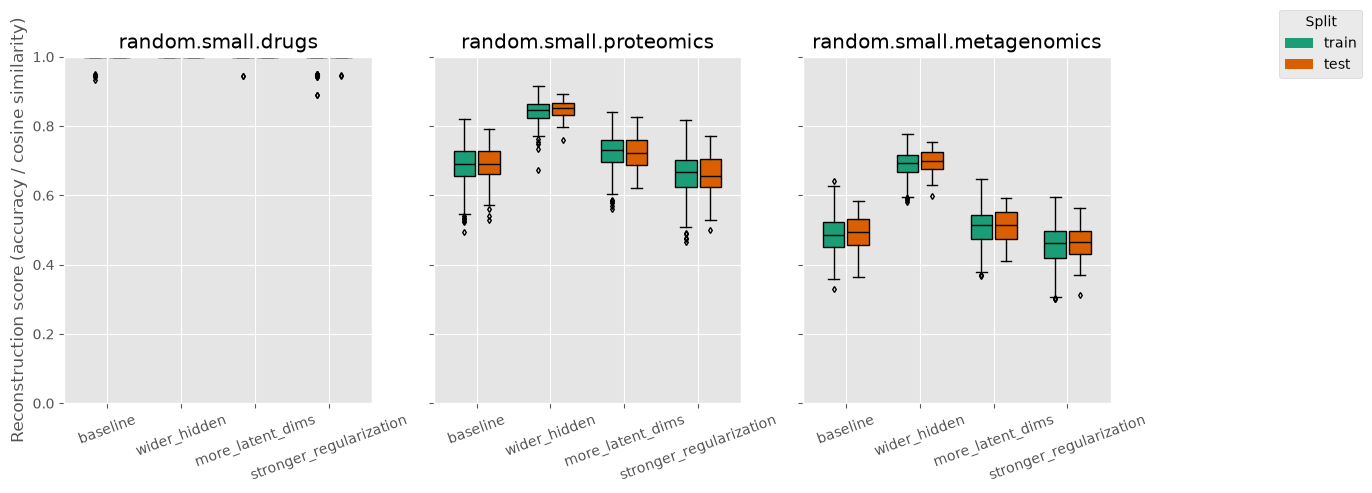

In [26]:
import numpy as np
import matplotlib.pyplot as plt

from move.visualization import show_figure
from move.visualization.style import (
    DEFAULT_PLOT_STYLE,
    DEFAULT_QUALITATIVE_PALETTE,
    color_cycle,
    style_settings,
)

combos = list(HP_COMBOS.keys())
datasets = hp_results_df["dataset"].unique()
splits = ["train", "test"]
x = np.arange(len(combos)) * 1.2  # one slot per combo, extra gap between slots

with style_settings(DEFAULT_PLOT_STYLE), color_cycle(DEFAULT_QUALITATIVE_PALETTE):
    colors = [c["color"] for c in list(plt.rcParams["axes.prop_cycle"])[: len(splits)]]
    fig, axs = plt.subplots(ncols=len(datasets), sharey=True, figsize=(4.5 * len(datasets), 4.5), squeeze=False)
    for ax, dataset_name in zip(axs[0], datasets):
        for split_name, color, offset in zip(splits, colors, (0.0, 0.4)):
            data = [
                hp_results_df.loc[
                    (hp_results_df["combo"] == combo)
                    & (hp_results_df["dataset"] == dataset_name)
                    & (hp_results_df["split"] == split_name),
                    "score",
                ]
                for combo in combos
            ]
            ax.boxplot(
                data,
                positions=x + offset,
                widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor=color),
                medianprops=dict(color="black"),
                flierprops=dict(marker="d", markersize=3),
            )
        ax.set(xticks=x + 0.2, xticklabels=combos, ylim=(0, 1), title=dataset_name)
        ax.tick_params(axis="x", rotation=20)
    axs[0, 0].set_ylabel("Reconstruction score (accuracy / cosine similarity)")
    fig.legend(
        handles=[plt.Rectangle((0, 0), 1, 1, facecolor=c) for c in colors],
        labels=splits,
        title="Split",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
    )
show_figure(fig)

## 5. Train a model & explore its latent space

Same task the tutorial's "04 Latent space analysis" notebook uses. Trains a VAE
(or reloads one already saved at `RESULTS_PATH/latent_space/model.pt`), then
projects the data into its latent space, scores reconstruction accuracy, and
computes feature importance. Plots (loss curve, reconstruction metrics, latent
space) are saved to `RESULTS_PATH/latent_space/` and shown inline below.

[INFO  - LatentSpaceAnalysis]: Epoch 10
[INFO  - LatentSpaceAnalysis]: Epoch 20
[INFO  - LatentSpaceAnalysis]: Epoch 30
[INFO  - LatentSpaceAnalysis]: Epoch 40


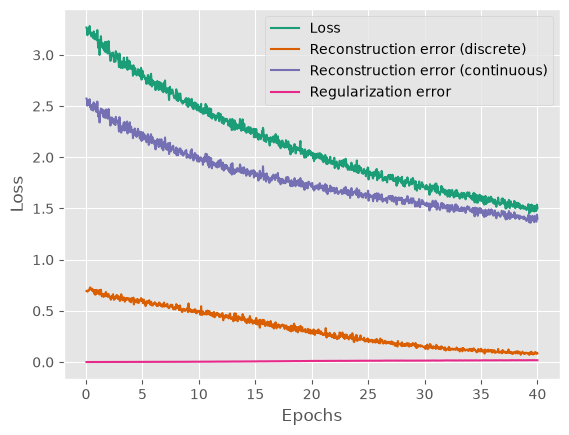

[INFO  - LatentSpaceAnalysis]: Compressing input data
[INFO  - LatentSpaceAnalysis]: Computing accuracy metrics


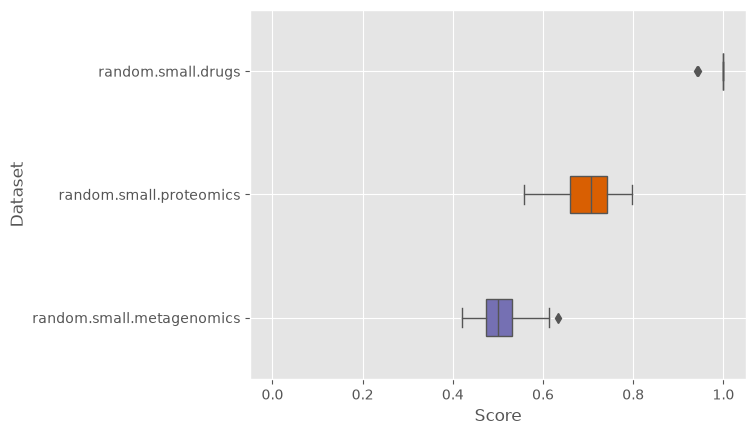

[INFO  - LatentSpaceAnalysis]: Computing feature importance: 'random.small.drugs'
[INFO  - LatentSpaceAnalysis]: Computing feature importance: 'random.small.proteomics'
[INFO  - LatentSpaceAnalysis]: Computing feature importance: 'random.small.metagenomics'


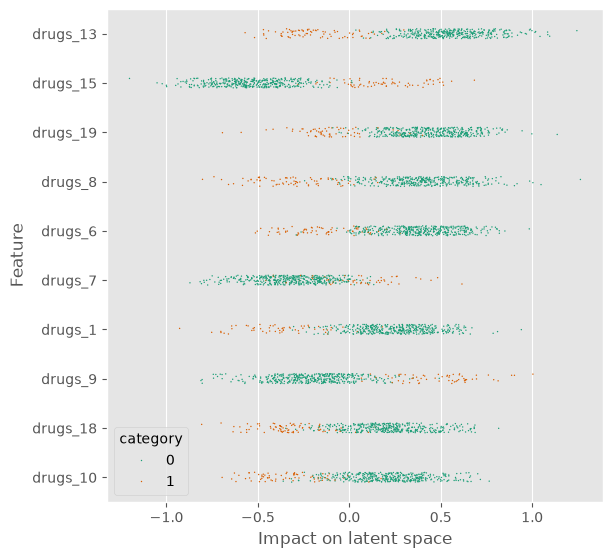

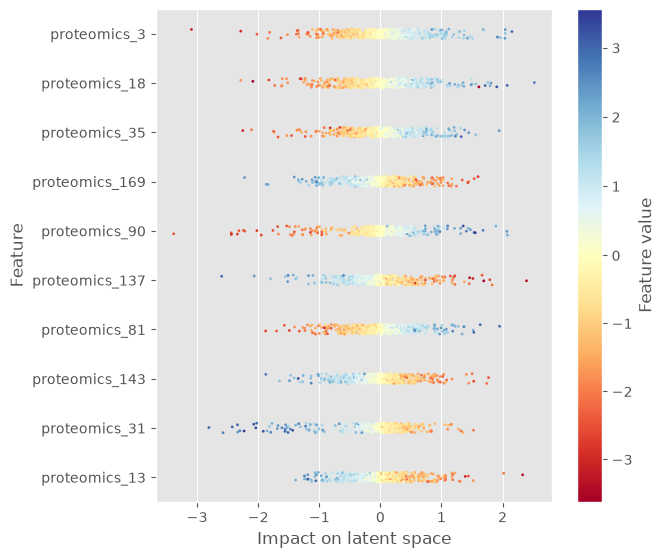

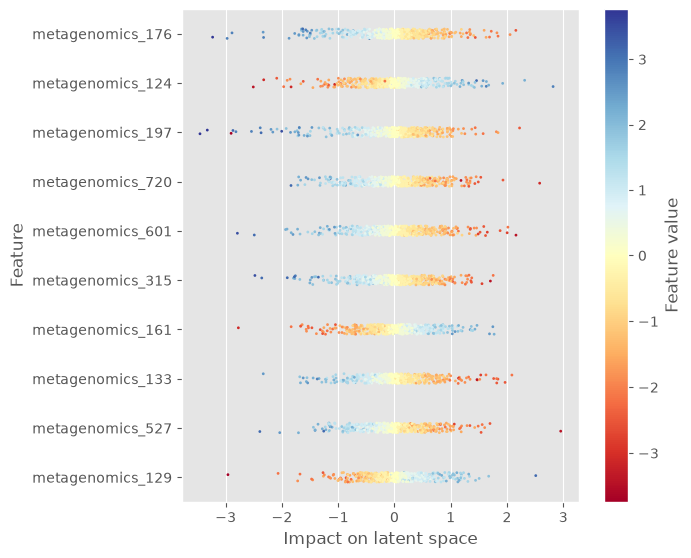

In [27]:
REDUCER_CONFIG = None
# from move.conf.tasks import PcaConfig, TsneConfig
# REDUCER_CONFIG = PcaConfig()  # or TsneConfig(), to reduce the latent space to 2D

FEATURES_TO_PLOT = None  # e.g. ["my_drug_dataset_20"] to color latent space plots by a feature

model_config = VaeConfig(
    num_hidden=NUM_HIDDEN,
    num_latent=NUM_LATENT,
    kl_weight=KL_WEIGHT,
    dropout_rate=DROPOUT_RATE,
    use_cuda=USE_CUDA,
    discrete_weights=CATEGORICAL_WEIGHTS,
    continuous_weights=CONTINUOUS_WEIGHTS,
)
training_loop_config = TrainingLoopConfig(
    max_epochs=MAX_EPOCHS,
    annealing_epochs=ANNEALING_EPOCHS,
    optimizer_config=AdamConfig(lr=LEARNING_RATE),
)

latent_task = LatentSpaceAnalysis(
    interim_data_path=INTERIM_DATA_PATH,
    results_path=RESULTS_PATH,
    discrete_dataset_names=CATEGORICAL_NAMES,
    continuous_dataset_names=CONTINUOUS_NAMES,
    batch_size=BATCH_SIZE,
    model_config=model_config,
    training_loop_config=training_loop_config,
    compute_accuracy_metrics=True,
    compute_feature_importance=True,
    reducer_config=REDUCER_CONFIG,
    features_to_plot=FEATURES_TO_PLOT,
)
latent_task.run()

### 5b. Explore the latent space — EDIT ME

Re-plots the 2D latent space using the model just trained above, without
retraining anything. Change `COLOR_BY_FEATURE` to color the scatterplot by
any feature from your datasets, and `REDUCER_CONFIG` to switch between PCA
and t-SNE for the dimensionality reduction. Re-run this cell as many times
as you like to try different features/reducers.

[INFO  - LatentSpaceAnalysis]: File 'results/latent_space/latent_space.csv' already exists. It will be overwritten.
[INFO  - LatentSpaceAnalysis]: Compressing input data
[INFO  - LatentSpaceAnalysis]: Reducing data to two dimensions


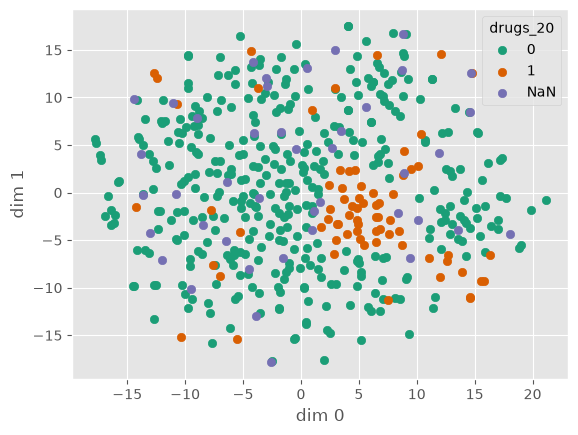

In [28]:
from move.conf.tasks import PcaConfig, TsneConfig
from move.models.base import reload_vae
from move.tasks.latent_space_analysis import Project

COLOR_BY_FEATURE = "drugs_20"  # a feature name from any of your datasets
REDUCER_CONFIG = TsneConfig()  # or PcaConfig(), to change the dimensionality reduction

model = reload_vae(latent_task.output_dir / latent_task.model_filename)
model.eval()
all_dataloader = latent_task.make_dataloader(shuffle=False, drop_last=False)

project_subtask = Project(model, all_dataloader, REDUCER_CONFIG, output_dir=latent_task.output_dir)
project_subtask.parent = latent_task
project_subtask.run()
project_subtask.plot([COLOR_BY_FEATURE])

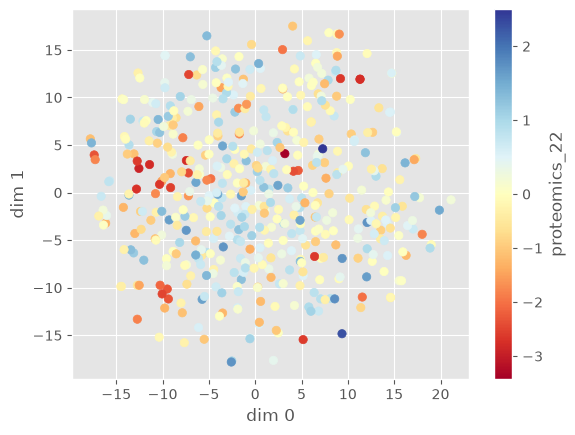

In [29]:
COLOR_BY_FEATURE = "proteomics_22" 
project_subtask.plot([COLOR_BY_FEATURE])

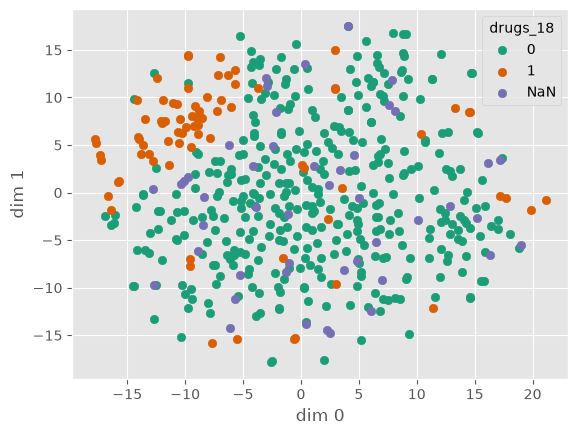

In [30]:
COLOR_BY_FEATURE = "drugs_18" 
project_subtask.plot([COLOR_BY_FEATURE])

## 6. Identify associations — EDIT ME

Perturbs a feature (or a whole dataset) and checks which continuous features
are significantly associated with it, via the Bayesian method.

⚠️ Note: the alternative t-test method mentioned in the original MOVE paper has
not been reimplemented for this codebase's current version — this always uses
the Bayesian approach.

By default this reuses `model_config`/`training_loop_config` from step 4; edit
them here first if you want different hyperparameters for this step.

In [31]:
TARGET_DATASET = "random.small.drugs"  # a name from CATEGORICAL_DATASETS above
TARGET_FEATURE = None                # perturb one feature only, or None for all features in TARGET_DATASET
TARGET_VALUE = 1                     # value to set the perturbed feature(s) to

NUM_REFITS = 40       # number of models to train and average results over
SIG_THRESHOLD = 0.05  # FDR threshold below which an association is "significant"

assoc_task = Associations(
    interim_data_path=INTERIM_DATA_PATH,
    results_path=RESULTS_PATH,
    discrete_dataset_names=CATEGORICAL_NAMES,
    continuous_dataset_names=CONTINUOUS_NAMES,
    batch_size=BATCH_SIZE,
    model_config=model_config,
    training_loop_config=training_loop_config,
    perturbation_config=PerturbationConfig(
        target_dataset_name=TARGET_DATASET,
        target_feature_name=TARGET_FEATURE,
        target_value=TARGET_VALUE,
    ),
    num_refits=NUM_REFITS,
    sig_threshold=SIG_THRESHOLD,
    write_only_sig=False,  # keep all features so the volcano plot below has a background
)
assoc_task.run()

associations = pd.read_csv(assoc_task.output_dir / "associations.csv")
associations.sort_values("fdr").head(20)

[INFO  - Associations]: Perturbing (1/20)
[INFO  - Associations]: Perturbing (2/20)
[INFO  - Associations]: Perturbing (3/20)
[INFO  - Associations]: Perturbing (4/20)
[INFO  - Associations]: Perturbing (5/20)
[INFO  - Associations]: Perturbing (6/20)
[INFO  - Associations]: Perturbing (7/20)
[INFO  - Associations]: Perturbing (8/20)
[INFO  - Associations]: Perturbing (9/20)
[INFO  - Associations]: Perturbing (10/20)
[INFO  - Associations]: Perturbing (11/20)
[INFO  - Associations]: Perturbing (12/20)
[INFO  - Associations]: Perturbing (13/20)
[INFO  - Associations]: Perturbing (14/20)
[INFO  - Associations]: Perturbing (15/20)
[INFO  - Associations]: Perturbing (16/20)
[INFO  - Associations]: Perturbing (17/20)
[INFO  - Associations]: Perturbing (18/20)
[INFO  - Associations]: Perturbing (19/20)
[INFO  - Associations]: Perturbing (20/20)
[INFO  - Associations]: Complete! Writing out results
[INFO  - Associations]: Significant associations found: 53


,perturbed_feature,target_feature,prob,bayes_k,fdr,pred_significant
0,drugs_6,proteomics_31,1.000000,18.420681,0.000000,True
1,drugs_15,metagenomics_633,1.000000,18.420681,0.000000,True
2,drugs_14,proteomics_79,1.000000,18.420681,0.000000,True
3,drugs_9,metagenomics_594,1.000000,-18.420681,0.000000,True
4,drugs_13,proteomics_118,1.000000,18.420681,0.000000,True
5,drugs_17,proteomics_197,1.000000,-18.420681,0.000000,True
6,drugs_10,metagenomics_146,0.976744,3.737669,0.003322,True
7,drugs_15,proteomics_189,0.976744,-3.737669,0.005814,True
8,drugs_2,metagenomics_930,0.975610,-3.688879,0.007878,True
9,drugs_4,proteomics_133,0.975610,-3.688879,0.009529,True


### 6b. Visualize associations — volcano plot

The Bayesian association test produces, per candidate feature: `bayes_k` (the
signed log-odds that the perturbation increases vs. decreases it — the
"effect") and `fdr` (confidence). Plotting one against the other, as a volcano
plot, is the standard way to see both at a glance: points far from `x=0` and
above the dashed line are your strongest, most confident hits.

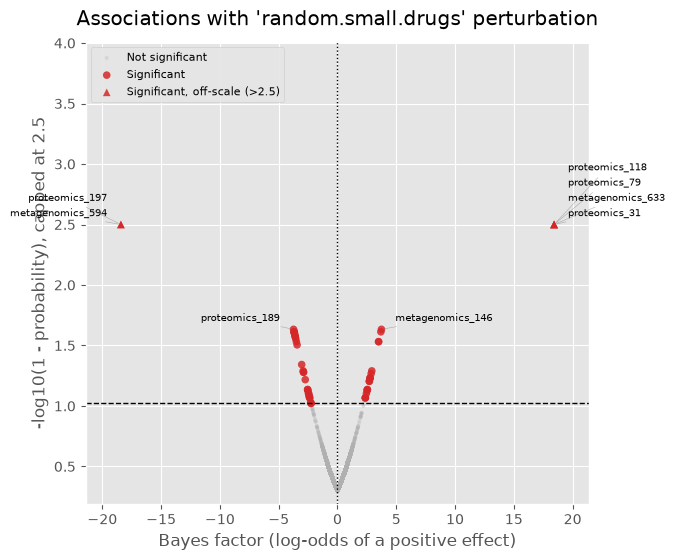

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit

from move.visualization import show_figure
from move.visualization.style import DEFAULT_PLOT_STYLE, style_settings

TOP_N_LABELS = 8   # how many of the most significant hits to label by name
Y_CAP = 2.5         # display cap for -log10(1 - probability); see note below

plot_df = associations.copy()

# `prob` in the CSV is a float32 sigmoid of |bayes_k|, so it rounds to
# exactly 1.0 once bayes_k saturates -- "1 - prob" would then be exactly 0
# and -log10 would blow up to infinity. Recomputing the complementary
# probability directly, expit(-|bayes_k|), keeps its true (tiny but
# nonzero) value instead, avoiding that entirely.
plot_df["neg_log10_1mp"] = -np.log10(expit(-plot_df["bayes_k"].abs().astype(np.float64)))

# Even without the infinity issue, a handful of "every sample agreed"
# associations sit far above the borderline ones (up to ~8 vs ~1-1.6), which
# would still squash the interesting gradient near the significance cutoff.
# Capping the display (and marking capped points distinctly) keeps that
# gradient readable without hiding that some hits are far more extreme.
plot_df["capped"] = plot_df["neg_log10_1mp"] > Y_CAP
plot_df["y_plot"] = plot_df["neg_log10_1mp"].clip(upper=Y_CAP)

with style_settings(DEFAULT_PLOT_STYLE):
    fig, ax = plt.subplots(figsize=(6.5, 6))

    background = plot_df[~plot_df["pred_significant"]]
    ax.scatter(
        background["bayes_k"], background["y_plot"],
        c="#b0b0b0", s=8, alpha=0.3, edgecolors="none",
        label="Not significant", rasterized=True,
    )

    sig = plot_df[plot_df["pred_significant"]]
    for capped, marker, label in [
        (False, "o", "Significant"),
        (True, "^", f"Significant, off-scale (>{Y_CAP:g})"),
    ]:
        subset = sig[sig["capped"] == capped]
        if len(subset):
            ax.scatter(
                subset["bayes_k"], subset["y_plot"],
                c="#d62728", marker=marker, s=30, alpha=0.85,
                edgecolors="none", label=label,
            )

    # The FDR ranking is itself a sort on this same probability, so a clean
    # separating line exists here too -- the least-confident significant hit
    # and the most-confident non-significant one never overlap.
    cutoff = (background["neg_log10_1mp"].max() + sig["neg_log10_1mp"].min()) / 2
    ax.axhline(cutoff, color="black", linestyle="--", linewidth=1)
    ax.axvline(0, color="black", linestyle=":", linewidth=1)

    # Multiple top hits often land on the exact same (capped) point -- e.g.
    # every unanimous perturbation saturates at the same ceiling -- so
    # labels are stacked per shared point (with a thin leader line) instead
    # of placed directly on top of each other.
    top_hits = plot_df.nsmallest(TOP_N_LABELS, "fdr")
    stack_counts: dict[tuple[float, float], int] = {}
    max_stack = 0
    for _, row in top_hits.iterrows():
        key = (round(row["bayes_k"], 2), round(row["y_plot"], 2))
        stack_idx = stack_counts.get(key, 0)
        stack_counts[key] = stack_idx + 1
        max_stack = max(max_stack, stack_idx)
        side = 1 if row["bayes_k"] >= 0 else -1
        ax.annotate(
            row["target_feature"], (row["bayes_k"], row["y_plot"]),
            fontsize=7, ha="left" if side > 0 else "right",
            xytext=(side * 10, 6 + 11 * stack_idx), textcoords="offset points",
            arrowprops=dict(arrowstyle="-", lw=0.4, color="gray", alpha=0.6),
        )

    y0, y1 = ax.get_ylim()
    ax.set_ylim(y0, y1 + 0.35 * (max_stack + 1))
    ax.set_xlim(plot_df["bayes_k"].min() - 3, plot_df["bayes_k"].max() + 3)

    ax.set(
        xlabel="Bayes factor (log-odds of a positive effect)",
        ylabel=f"-log10(1 - probability), capped at {Y_CAP:g}",
    )
    ax.set_title(f"Associations with '{TARGET_DATASET}' perturbation", pad=12)
    ax.legend(loc="upper left", fontsize=8, framealpha=0.9)
show_figure(fig)

### 6c. Test: continuous feature perturbations — NEW

Ported from `main`'s "Continuous perturbations" commit onto this branch's
current architecture (`Perturbation`/`MoveDataset.perturb()` in
`move/data/dataset.py`, `PerturbationConfig` in `move/conf/tasks.py`).

Until now, perturbing a feature meant replacing every sample's value with one
fixed `target_value` — sensible for a categorical drug feature ("set to 1"),
less so for a continuous omics feature, since a single hardcoded number
rarely means the same thing across differently-scaled features.

`PerturbationConfig` now takes an optional `perturbation_type`, continuous
datasets only:

- `"value"` (default, unchanged) — replace with `target_value`
- `"minimum"` / `"maximum"` — replace with the feature's own dataset-wide min/max
- `"plus_std"` / `"minus_std"` — add/subtract one standard deviation **to each
  sample's own existing value**, rather than replacing it (this one needed a
  real code change: the existing `Perturbation` only knew how to broadcast a
  fixed replacement value, not offset each sample individually)

Below, we perturb a single continuous feature with each type and compare how
many associations each finds — a quick way to confirm the new code path
actually runs through the full `Associations` task, not just in isolation.

In [34]:
CONTINUOUS_TARGET_DATASET = "random.small.proteomics"
CONTINUOUS_TARGET_FEATURE = None  # None = every feature in CONTINUOUS_TARGET_DATASET (200 for proteomics)

PERTURBATION_TYPES = ["minimum", "maximum", "plus_std", "minus_std"]
CONTINUOUS_NUM_REFITS = 3  # lower than NUM_REFITS above -- see runtime note below

# Runtime note: with target_feature_name=None this trains
# (# features in the dataset) x len(PERTURBATION_TYPES) x CONTINUOUS_NUM_REFITS
# models -- for all 200 proteomics features x 4 types x 3 refits, that's 2,400
# trainings of MAX_EPOCHS epochs each (reused from training_loop_config above).
# That's a lot more than the single-feature version this replaced. Dial the
# knobs above down further (fewer PERTURBATION_TYPES, lower
# CONTINUOUS_NUM_REFITS, or a separate faster TrainingLoopConfig with fewer
# epochs just for this exploratory cell) if this is too slow to run in full.

continuous_perturbation_results = {}
for ptype in PERTURBATION_TYPES:
    print(f"--- perturbation_type={ptype} ---")
    task = Associations(
        interim_data_path=INTERIM_DATA_PATH,
        results_path=Path(RESULTS_PATH) / "continuous_perturbation_test" / ptype,
        discrete_dataset_names=CATEGORICAL_NAMES,
        continuous_dataset_names=CONTINUOUS_NAMES,
        batch_size=BATCH_SIZE,
        model_config=model_config,
        training_loop_config=training_loop_config,
        perturbation_config=PerturbationConfig(
            target_dataset_name=CONTINUOUS_TARGET_DATASET,
            target_feature_name=CONTINUOUS_TARGET_FEATURE,
            target_value=0.0,  # ignored for every type here except "value"
            perturbation_type=ptype,
        ),
        num_refits=CONTINUOUS_NUM_REFITS,
        sig_threshold=SIG_THRESHOLD,
        write_only_sig=False,
    )
    task.run()
    continuous_perturbation_results[ptype] = pd.read_csv(task.output_dir / "associations.csv")

# Which specific (perturbed_feature, target_feature) pairs were significant under
# each perturbation type -- not just how many.
significant_by_type = []
for ptype, df in continuous_perturbation_results.items():
    sig = df[df["pred_significant"]].copy()
    sig.insert(0, "perturbation_type", ptype)
    significant_by_type.append(sig)

significant_associations = pd.concat(significant_by_type, ignore_index=True)
significant_associations.sort_values(["perturbation_type", "fdr"])

[INFO  - Associations]: File 'results/continuous_perturbation_test/minimum/associations/associations.csv' already exists. It will be overwritten.
[INFO  - Associations]: Perturbing (1/200)


--- perturbation_type=minimum ---


[INFO  - Associations]: Perturbing (2/200)
[INFO  - Associations]: Perturbing (3/200)
[INFO  - Associations]: Perturbing (4/200)
[INFO  - Associations]: Perturbing (5/200)
[INFO  - Associations]: Perturbing (6/200)
[INFO  - Associations]: Perturbing (7/200)
[INFO  - Associations]: Perturbing (8/200)
[INFO  - Associations]: Perturbing (9/200)
[INFO  - Associations]: Perturbing (10/200)
[INFO  - Associations]: Perturbing (11/200)
[INFO  - Associations]: Perturbing (12/200)
[INFO  - Associations]: Perturbing (13/200)
[INFO  - Associations]: Perturbing (14/200)
[INFO  - Associations]: Perturbing (15/200)
[INFO  - Associations]: Perturbing (16/200)
[INFO  - Associations]: Perturbing (17/200)
[INFO  - Associations]: Perturbing (18/200)
[INFO  - Associations]: Perturbing (19/200)
[INFO  - Associations]: Perturbing (20/200)
[INFO  - Associations]: Perturbing (21/200)
[INFO  - Associations]: Perturbing (22/200)
[INFO  - Associations]: Perturbing (23/200)
[INFO  - Associations]: Perturbing (24/2

--- perturbation_type=maximum ---


[INFO  - Associations]: Perturbing (3/200)
[INFO  - Associations]: Perturbing (4/200)
[INFO  - Associations]: Perturbing (5/200)
[INFO  - Associations]: Perturbing (6/200)
[INFO  - Associations]: Perturbing (7/200)
[INFO  - Associations]: Perturbing (8/200)
[INFO  - Associations]: Perturbing (9/200)
[INFO  - Associations]: Perturbing (10/200)
[INFO  - Associations]: Perturbing (11/200)
[INFO  - Associations]: Perturbing (12/200)
[INFO  - Associations]: Perturbing (13/200)
[INFO  - Associations]: Perturbing (14/200)
[INFO  - Associations]: Perturbing (15/200)
[INFO  - Associations]: Perturbing (16/200)
[INFO  - Associations]: Perturbing (17/200)
[INFO  - Associations]: Perturbing (18/200)
[INFO  - Associations]: Perturbing (19/200)
[INFO  - Associations]: Perturbing (20/200)
[INFO  - Associations]: Perturbing (21/200)
[INFO  - Associations]: Perturbing (22/200)
[INFO  - Associations]: Perturbing (23/200)
[INFO  - Associations]: Perturbing (24/200)
[INFO  - Associations]: Perturbing (25/

--- perturbation_type=plus_std ---


[INFO  - Associations]: Perturbing (2/200)
[INFO  - Associations]: Perturbing (3/200)
[INFO  - Associations]: Perturbing (4/200)
[INFO  - Associations]: Perturbing (5/200)
[INFO  - Associations]: Perturbing (6/200)
[INFO  - Associations]: Perturbing (7/200)
[INFO  - Associations]: Perturbing (8/200)
[INFO  - Associations]: Perturbing (9/200)
[INFO  - Associations]: Perturbing (10/200)
[INFO  - Associations]: Perturbing (11/200)
[INFO  - Associations]: Perturbing (12/200)
[INFO  - Associations]: Perturbing (13/200)
[INFO  - Associations]: Perturbing (14/200)
[INFO  - Associations]: Perturbing (15/200)
[INFO  - Associations]: Perturbing (16/200)
[INFO  - Associations]: Perturbing (17/200)
[INFO  - Associations]: Perturbing (18/200)
[INFO  - Associations]: Perturbing (19/200)
[INFO  - Associations]: Perturbing (20/200)
[INFO  - Associations]: Perturbing (21/200)
[INFO  - Associations]: Perturbing (22/200)
[INFO  - Associations]: Perturbing (23/200)
[INFO  - Associations]: Perturbing (24/2

--- perturbation_type=minus_std ---


[INFO  - Associations]: Perturbing (3/200)
[INFO  - Associations]: Perturbing (4/200)
[INFO  - Associations]: Perturbing (5/200)
[INFO  - Associations]: Perturbing (6/200)
[INFO  - Associations]: Perturbing (7/200)
[INFO  - Associations]: Perturbing (8/200)
[INFO  - Associations]: Perturbing (9/200)
[INFO  - Associations]: Perturbing (10/200)
[INFO  - Associations]: Perturbing (11/200)
[INFO  - Associations]: Perturbing (12/200)
[INFO  - Associations]: Perturbing (13/200)
[INFO  - Associations]: Perturbing (14/200)
[INFO  - Associations]: Perturbing (15/200)
[INFO  - Associations]: Perturbing (16/200)
[INFO  - Associations]: Perturbing (17/200)
[INFO  - Associations]: Perturbing (18/200)
[INFO  - Associations]: Perturbing (19/200)
[INFO  - Associations]: Perturbing (20/200)
[INFO  - Associations]: Perturbing (21/200)
[INFO  - Associations]: Perturbing (22/200)
[INFO  - Associations]: Perturbing (23/200)
[INFO  - Associations]: Perturbing (24/200)
[INFO  - Associations]: Perturbing (25/

,perturbation_type,perturbed_feature,target_feature,prob,bayes_k,fdr,pred_significant
